# Retail Decision Intelligence Platform

## Module 2: Feature Engineering

### Objective

The purpose of feature engineering is to transform the cleaned transactional dataset into an analysis-ready dataset by creating meaningful business features.

These engineered features will support:

- Revenue Analysis
- Customer Analytics
- Time Series Analysis
- Sales Forecasting
- Power BI Dashboard
- SQL Business Queries

In [3]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [6]:
#Load Cleaned Data
sales_df = pd.read_csv("../data/cleaned/sales_data.csv",parse_dates=["InvoiceDate"])
sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
#Dataset Information
print("Dataset Shape:", sales_df.shape)

sales_df.info()

Dataset Shape: (504730, 8)
<class 'pandas.DataFrame'>
RangeIndex: 504730 entries, 0 to 504729
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      504730 non-null  int64         
 1   StockCode    504730 non-null  str           
 2   Description  504730 non-null  str           
 3   Quantity     504730 non-null  int64         
 4   InvoiceDate  504730 non-null  datetime64[us]
 5   Price        504730 non-null  float64       
 6   Customer ID  400916 non-null  float64       
 7   Country      504730 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(2), str(3)
memory usage: 30.8 MB


In [10]:
#Create Revenue Feature
sales_df["Revenue"] = (sales_df["Quantity"] * sales_df["Price"])
sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## Revenue Feature

Revenue is calculated as:

Revenue = Quantity × Unit Price

This feature is fundamental for almost every business analysis including:

- Sales Trends
- Product Performance
- Country Revenue
- Customer Value
- Forecasting

In [11]:
#Validating Revenue
sales_df["Revenue"].describe()

count    504730.000000
mean         20.351005
std          91.509716
min           0.001000
25%           4.200000
50%          10.200000
75%          17.700000
max       25111.090000
Name: Revenue, dtype: float64

In [16]:
total_revenue = sales_df["Revenue"].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $10,271,762.66


In [17]:
sales_df["Revenue"].head(10)

0     83.4
1     81.0
2     81.0
3    100.8
4     30.0
5     39.6
6     30.0
7     59.5
8     30.6
9     45.0
Name: Revenue, dtype: float64

<Axes: >

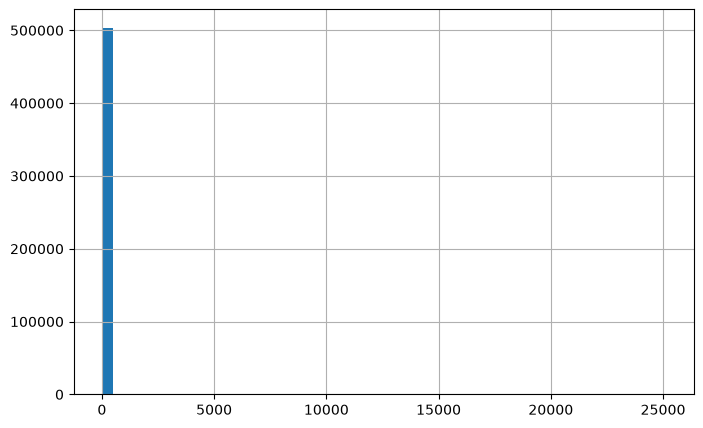

In [18]:
#Revenue Distribution
sales_df["Revenue"].hist(bins=50,figsize=(8,5))

# Time-Based Feature Engineering

Transaction timestamps contain valuable business information.

Instead of repeatedly extracting date components during analysis, separate time-based features are created.

These features enable:

- Monthly Sales Trend
- Quarterly Revenue Analysis
- Peak Shopping Hours
- Day-wise Sales
- Weekend vs Weekday Analysis
- Seasonal Business Insights

In [22]:
#Yearly 
sales_df["Year"] = sales_df["InvoiceDate"].dt.year
sales_df["Year"].value_counts()

Year
2010    461277
2009     43453
Name: count, dtype: int64

In [24]:
#Quaterly
sales_df["Quarter"] = sales_df["InvoiceDate"].dt.quarter
sales_df["Quarter"].value_counts().sort_index()

Quarter
1     98110
2    104632
3    104851
4    197137
Name: count, dtype: int64

In [25]:
#Month Number
sales_df["Month"] = sales_df["InvoiceDate"].dt.month
sales_df["Month"].value_counts().sort_index()

Month
1     30317
2     27952
3     39841
4     32858
5     33383
6     38391
7     32112
8     32109
9     40630
10    56953
11    75035
12    65149
Name: count, dtype: int64

In [26]:
#Month Name
sales_df["MonthName"] = sales_df["InvoiceDate"].dt.month_name()
sales_df["MonthName"].value_counts()

MonthName
November     75035
December     65149
October      56953
September    40630
March        39841
June         38391
May          33383
April        32858
July         32112
August       32109
January      30317
February     27952
Name: count, dtype: int64

In [30]:
#Day
sales_df["Day"] = sales_df["InvoiceDate"].dt.day
sales_df["Day"].value_counts()
sales_df["DayName"] = sales_df["InvoiceDate"].dt.day_name()
sales_df["DayName"].value_counts()

DayName
Thursday     95039
Monday       90905
Tuesday      90522
Wednesday    87146
Sunday       72176
Friday       68542
Saturday       400
Name: count, dtype: int64

In [36]:
#Week Number
sales_df["Week"] = sales_df["InvoiceDate"].dt.isocalendar().week
sales_df["Week"].head()

0    49
1    49
2    49
3    49
4    49
Name: Week, dtype: UInt32

In [38]:
#Hour
sales_df["Hour"] = sales_df["InvoiceDate"].dt.hour
sales_df["Hour"].value_counts().sort_index()

Hour
7       685
8      6878
9     33306
10    42546
11    61321
12    78010
13    74932
14    71595
15    55357
16    37685
17    27756
18     8553
19     4921
20     1185
Name: count, dtype: int64

In [39]:
#Weekend
sales_df["Weekend"] = sales_df["DayName"].isin(["Saturday","Sunday"])
sales_df["Weekend"].value_counts()

Weekend
False    432154
True      72576
Name: count, dtype: int64

In [40]:
#Updating the dataset with new features
sales_df.to_csv("../data/cleaned/sales_features.csv",index=False)